# Profit Shifting in a Minimal Production Environment

This notebook presents a controlled simulation designed to illustrate how **profit-shifting strategies** can emerge even in the simplest possible economic environment.  
The experiment progressively introduces fiscal and price differentials to show how these mechanisms affect the optimal allocation of production stages between two jurisdictions.

## Objective
To demonstrate, through a step-by-step ablation, how tax and pricing asymmetries can lead firms to reallocate production and strategically report profits, even when the underlying production structure is simple and transparent.

## Economic setting
The model considers two jurisdictions with distinct **tax regimes**:

- **National Customs Territory (NCT):** represents the domestic economy, where corporate income is taxed at the standard rate and where all final sales are directed toward the local market.  
- **Free Trade Zone (FTZ):** a geographically separated area that operates under a **preferential tax rate**, typically designed to promote exports and foreign investment.  
  Firms in the FTZ are legally independent but may belong to the same corporate group as those located in the NCT.

A third agent — the **Market (MKT)** — supplies the initial inputs and purchases the final good.  
Both the NCT and FTZ firms can buy intermediate goods or inputs from each other, and they can sell intermediate goods to one another or to the market depending on the scenario.

In this configuration, the **NCT firm** owns or controls a related entity operating in the **FTZ**.  
The FTZ firm produces goods that can be send into the NCT, allowing part of the profits to be recorded under the lower-tax jurisdiction.  
The final good is always sold domestically by the **NCT firm**, which acts as the official seller.

This structure reproduces a typical **intragroup transaction system**: two legally distinct firms, under common ownership, exchange goods across jurisdictions to minimize the group’s overall tax liability.

## Methodology
The experiment unfolds in three stages:

1. **Base scenario:** identical corporate tax rates and symmetric prices between NCT and FTZ.  
2. **Tax differential:** the FTZ faces a lower corporate income tax rate than the NCT.  
3. **Price differentiation:** intra-group transactions between NCT and FTZ can occur at prices different from those applied to the external market.

For each stage:
- A **linear production graph** is defined, consisting of four goods  
  *Input → Intermediate 1 → Intermediate 2 → Final Good*.  
- A corresponding **price matrix** encodes the economic parameters of the scenario.  
- The **Macro–Micro Genetic Algorithm** searches for the optimal assignment of production stages between jurisdictions.  
- After each run, the **accounting statements** of each agent are analyzed to examine how profits and taxes are distributed.

## Key modeling assumptions
- The **NCT firm** always performs the **final sale** of the good to the domestic market.  
- The **Market (MKT)** supplies inputs and purchases the final output at externally determined prices.  
- In scenarios 2 and 3, the **transfer prices** of transactions between the NCT and FTZ firms deviate from market prices.  
- The goal of each scenario is not only to find the maximizing configuration but also to observe how **accounting outcomes evolve** as fiscal and pricing asymmetries are introduced.

## Expected results
- In the base scenario, all configurations are **equivalent**: there is no fiscal or price incentive to locate production in one jurisdiction or another.  
- When tax rates differ, production tends to be concentrated in the **low-tax jurisdiction (FTZ)**, while the NCT firm captures revenues from final sales to the market.  
- When transfer prices vary, **profit-shifting strategies** become more complex and harder to detect through standard financial reporting, as intra-group exchanges obscure the true allocation of value added.

> **Notes:**  
> - **NCT:** National Customs Territory (domestic, full-tax jurisdiction)  
> - **FTZ:** Free Trade Zone (preferential-tax jurisdiction focused on exports)  
> - **MKT:** market or final consumer  
> - This ablation serves as a validation exercise for the broader accounting and production framework developed in the main model.


## Production structure

The production process is represented as a **linear sequence of four stages**:

**Input → Intermediate 1 → Intermediate 2 → Final Good**

Each stage transforms the output of the previous one into a more advanced good until a final product is obtained and sold to the domestic market by the firm located in the **NCT**.  
Both firms — the one operating in the NCT and its related affiliate in the FTZ — can potentially undertake any stage of the production chain.

The figure below illustrates the topology of this simple production environment.


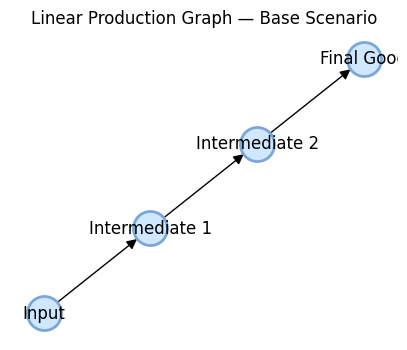

*Figure 1. Linear production process with four sequential stages.*

In [1]:
# === Build and visualize the base environment ===
from helpers_ablation import build_environment, draw_dag_topo, describe_price_matrix
import networkx as nx
import matplotlib.pyplot as plt

# Load the base scenario
G_links, P, AGENTS, hp = build_environment(method="macro_micro", case="Base")

# Create and draw the graph
G = nx.DiGraph()
G.add_edges_from(G_links)
draw_dag_topo(G, title="Linear Production Graph — Base Scenario")
plt.show()

# Add a markdown-style caption manually
from IPython.display import Markdown
display(Markdown("*Figure 1. Linear production process with four sequential stages.*"))


## 1. Scenario 1 — Base environment

The **base scenario** establishes a neutral benchmark in which no jurisdictional advantage exists.  
Both the National Customs Territory (NCT) and the Free Trade Zone (FTZ) face the same **corporate income tax rate of 35 %**, and all goods are exchanged at **symmetric prices** across agents.

In this environment:

- Both firms purchase their initial inputs from the **market (MKT)** at the same price.  
- Intermediate goods may be transacted either internally (between NCT and FTZ) or externally (with MKT), but prices are identical in every case.  
- The **final sale** is always carried out by the NCT firm to the domestic market.

Under these assumptions, no profit-shifting opportunities arise: every possible allocation of production stages yields the same after-tax profit.

The following tables summarize the fiscal parameters and the symmetric price structure used in this baseline configuration.


### Corporate income tax rates — Base scenario

| Jurisdiction | Tax rate (%) | Description |
|:--------------|:------------:|:-------------|
| **NCT** | 35 | National Customs Territory — domestic jurisdiction subject to the standard rate. |
| **FTZ** | 35 | Free Trade Zone — preferential regime, but identical rate in the base case. |

> Both jurisdictions face the **same 35% corporate income tax rate**, eliminating any fiscal incentive to shift profits.


---

### Price matrix — Base scenario

The table below summarizes all possible transactions between agents.  
Each row represents a **good**, and columns represent the **direction of trade** between the Market (MKT), the National Customs Territory firm (NCT), and the Free Trade Zone firm (FTZ).

| Good | MKT→NCT | MKT→FTZ | NCT→FTZ | FTZ→NCT | NCT→MKT | FTZ→MKT |
|:------|:-------:|:-------:|:-------:|:-------:|:-------:|:-------:|
| **Input**          | 100 | 100 | 100 | 100 | 100 | 100 |
| **Intermediate 1** | 101 | 101 | 101 | 101 | 101 | 101 |
| **Intermediate 2** | 102 | 102 | 102 | 102 | 102 | 102 |
| **Final Good**     | 103 | 103 | 103 | 103 | **105** | **105** |

> **Interpretation:**  
> - Prices increase unit by unit along the production chain (100 → 101 → 102 → 103), capturing the accumulation of value added at each stage.
> - All cross-border and domestic trades occur at identical prices, meaning there are no transfer-price differentials between the National Customs Territory (NCT) and the Free Trade Zone (FTZ).  
> - The final good is sold to the market (MKT) at a higher price (105), reflecting its completion and the premium of final demand.

---


## Running the Base Scenario: Fiscal Symmetry

In this first experiment, both jurisdictions face identical fiscal conditions.  
To ensure the optimization remains neutral to tax asymmetries, we temporarily override the system’s tax policy resolver so that every agent, including the Free Trade Zone (FTZ) firm, applies the **StandardPolicy (35%)** during the run.

This override is confined to this cell only — subsequent scenarios will restore the default configuration, where the FTZ operates under a preferential regime.


In [2]:
# ============================================================
# Symmetry verification (all genomes under 35%–35%)
# ============================================================
from helpers_ablation import build_environment
from algorithms.ga.macro_micro import _make_macro_micro_evaluator, _build_class_pools
from algorithms.ga.common import detect_prefix_layout_and_sizes, probe_allowed_indices_via_tx_builder
from decimal import Decimal
import classes.economy.agent.reporting.income_statement as inc
import numpy as np
import itertools
import pandas as pd
import types

# 1️⃣ Override tax rates just for this run
inc.DEFAULT_TAX_RATE = Decimal("0.35")
inc.ZF_TAX_RATE = Decimal("0.35")
print("✅ Both jurisdictions now taxed at 35% for symmetry test.\n")

# 2️⃣ Build environment
G_links, P, AGENTS, hp = build_environment(method="macro_micro", case="Base")

# 3️⃣ Prepare evaluator
labels, sizes, index_sets, tx_builder, L_min, _ = detect_prefix_layout_and_sizes(G_links, mode="graph")
K = int(sum(sizes))
L_used = max(int(L_min), K + 1)
alphabet = probe_allowed_indices_via_tx_builder(L_used, tx_builder, max_index_probe=3)
pools, pool_sizes = _build_class_pools(alphabet, sizes, per_good_cap=None, rng=np.random.default_rng(0))
evaluator = _make_macro_micro_evaluator(
    production_graph=G_links,
    pmatrix=P,
    agents_information=AGENTS,
    pools=pools,
    index_sets=index_sets,
    alphabet=alphabet,
    L_used=L_used,
    K=K,
    fix_last_gene=True,
)

# 4️⃣ Create DEAP-like dummy individuals to avoid attribute errors
class DummyIndividual(list):
    """Mimics DEAP Individual to satisfy evaluator expectations."""
    def __init__(self, data):
        super().__init__(data)
        self._phenotype = None

# 5️⃣ Generate all binary genomes (last gene fixed to 1 = sale by NCT)
n_genes = L_used
genomes = [list(g) + [1] for g in itertools.product([0, 1], repeat=n_genes - 1)]

# 6️⃣ Evaluate all genomes
results = []
for g in genomes:
    ind = DummyIndividual(g)
    fitness = evaluator(ind)[0]
    results.append({"Genome": "".join(map(str, g)), "Utility": fitness})

df = pd.DataFrame(results).sort_values("Utility", ascending=False)

# 7️⃣ Display
print(f"Evaluated {len(df)} genomes under fiscal symmetry (35%–35%)\n")
display(df)

# 8️⃣ Check equality
if np.allclose(df["Utility"], df["Utility"].iloc[0], atol=1e-9):
    print("✅ Perfect symmetry confirmed: all genomes yield identical utilities.")
else:
    print("⚠️ Utilities differ: possible hidden asymmetry in economy or rounding effects.")


✅ Both jurisdictions now taxed at 35% for symmetry test.

Evaluated 16 genomes under fiscal symmetry (35%–35%)



,Genome,Utility
0,00001,3.25
1,00011,3.25
2,00101,3.25
3,00111,3.25
4,01001,3.25
5,01011,3.25
6,01101,3.25
7,01111,3.25
8,10001,3.25
9,10011,3.25


✅ Perfect symmetry confirmed: all genomes yield identical utilities.


The previous run confirmed that **all genomes yield the same utility** when both jurisdictions face a 35% tax rate and transaction prices are fully symmetric.  
This result implies that, under fiscal symmetry, **the allocation of production stages between the NCT and FTZ is irrelevant**: profits and tax payments remain identical regardless of how production is distributed.

To visualize this equivalence, we can open the graphical interface (GUI) that reconstructs the full accounting and production flow for any given genome.  
In particular, we will inspect the two extreme configurations:

- `00001`: all production stages in the **NCT** (the domestic firm handles every process).  
- `11111`: all production stages in the **FTZ** (the affiliate in the Free Trade Zone handles all processes).

Both genomes produce the same financial outcome, as can be verified by substituting each into the GUI below.  

> **How to use the GUI:**  
> 1. Run the next code cell.  
> 2. When the interface opens, paste the genome you wish to analyze into the **“Genome”** field in the third column.  
> 3. Press the run button.
> 4. The system will automatically recompute the full set of transactions, taxes, and utilities for that configuration.


In [ ]:
# ============================================================
# GUI Launcher — Symmetric Baseline Inspection (portable path)
# ============================================================
import subprocess
import sys
import os
from textwrap import indent
from pathlib import Path
import numpy as np
from decimal import Decimal
import classes.economy.agent.reporting.income_statement as inc
from helpers_ablation import build_environment

# ------------------------------------------------------------
# 1️⃣ Restore fiscal setup
# ------------------------------------------------------------
inc.DEFAULT_TAX_RATE = Decimal("0.35")  # NCT
inc.ZF_TAX_RATE = Decimal("0.20")       # FTZ
print("✅ Fiscal setup restored — NCT: 35%, FTZ: 20%\n")

# ------------------------------------------------------------
# 2️⃣ Build symmetric environment
# ------------------------------------------------------------
G_links, P, AGENTS, hp = build_environment(method="macro_micro", case="Base")

# ------------------------------------------------------------
# 3️⃣ Find repository root and GUI path robustly
# ------------------------------------------------------------
cur = Path.cwd()
REPO_ROOT = None
while cur != cur.parent:
    if (cur / "tests").exists() and (cur / "classes").exists():
        REPO_ROOT = cur
        break
    cur = cur.parent

if REPO_ROOT is None:
    raise RuntimeError("❌ Could not locate repository root (no 'tests' and 'classes' folder found).")

GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"
gui_rel = os.path.relpath(GUI_PATH, Path.cwd())

print(f"📁 GUI path resolved (relative): {gui_rel}")
if not GUI_PATH.exists():
    raise FileNotFoundError(f"❌ GUI script not found at: {GUI_PATH.resolve()}")

# ------------------------------------------------------------
# 4️⃣ Prepare data for GUI
# ------------------------------------------------------------
graph_links_str = repr(G_links)
price_matrix_str = repr(P.tolist())
example_genome = "[0, 0, 0, 0, 1]"

# ------------------------------------------------------------
# 5️⃣ Inject environment variables
# ------------------------------------------------------------
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = example_genome
os.environ["ECON_AUTO_RUN"] = "1"

print("\n🧩 GUI handoff summary:")
print(indent(f"Graph links: {graph_links_str}", "  "))
print(indent(f"Price matrix shape: {P.shape}", "  "))
print(indent(f"Example genome: {example_genome}", "  "))
print(indent(f"GUI path: {gui_rel}", "  "))
print("\n👉 Once the GUI opens, you can paste any genome such as [1,1,1,1,1] or [0,0,0,0,1].\n")

# ------------------------------------------------------------
# 6️⃣ Launch GUI
# ------------------------------------------------------------
def launch_gui(open_now: bool = True):
    """Launch the Tkinter-based Economy GUI."""
    if not GUI_PATH.exists():
        print(f"❌ GUI script not found at: {GUI_PATH}")
        return
    cmd = [sys.executable, "-c", f"import sys, runpy; sys.path.insert(0, {repr(str(REPO_ROOT))}); from decimal import Decimal; import classes.economy.agent.reporting.income_statement as inc; inc.DEFAULT_TAX_RATE=Decimal('0.35'); inc.ZF_TAX_RATE=Decimal('0.35'); runpy.run_path({repr(str(GUI_PATH))}, run_name='__main__')"]
    print("🚀 Launching GUI:", " ".join(cmd))
    if open_now:
        subprocess.Popen(cmd, shell=False)

# ------------------------------------------------------------
# 7️⃣ Launch and cleanup
# ------------------------------------------------------------
open_immediately = True
if open_immediately:
    launch_gui(open_now=True)

for var in ["ECON_LINKS", "ECON_PRICE_MATRIX", "ECON_GENOME", "ECON_AUTO_RUN"]:
    os.environ.pop(var, None)

print("🧹 Environment variables cleared after launch.\n")


The following table presents the **production plan** corresponding to genome `11111`, in which the National Customs Territory (**NCT**) performs all production stages.

| **#** | **Action**                   | **Agents**                        |
|:-----:|------------------------------|-----------------------------------|
| 1 | **Buy Input**                   | Buyer: NCT &nbsp;&nbsp; Seller: MKT |
| 2 | **Produce Intermediate Good 1** | NCT                               |
| 3 | **Produce Intermediate Good 2** | NCT                               |
| 4 | **Produce Final Good**          | NCT                               |
| 5 | **Sell Final Good**             | Buyer: MKT &nbsp;&nbsp; Seller: NCT |

The next figure shows the **income statement of the NCT-located firm** for this configuration.  

![Income Statement — NCT under symmetric baseline](Base_Scenario.png)

The **Total Net Profit** and **Tax Expense** unser this scenario are:

| **Metric**              | **Value (in monetary units)** |
|:------------------------:|------------------------------:|
| **Total Net Profit**     | 3.25 |
| **Total Tax Expense**    | 1.75 |

---








## 2. Scenario 2 — Fiscal Asymmetry (Tax Differential)

The second scenario relaxes the assumption of fiscal symmetry while keeping all prices identical across agents.  
Here, the Free Trade Zone (**FTZ**) benefits from a **preferential corporate income tax rate of 20 %**, whereas the National Customs Territory (**NCT**) remains subject to the standard **35 %** rate.  

This configuration isolates the **pure tax effect** on firms’ location decisions: production costs and sales prices are unchanged,  
so any shift in the optimal allocation of production stages directly reflects the fiscal differential.

In this environment:

- Both firms continue to buy their inputs from the **market (MKT)** at identical prices.  
- Intermediate goods are still transacted at **symmetric transfer prices** between agents.  
- The only difference lies in the **tax rate applied to each jurisdiction**.

The following tables summarize the fiscal parameters and the symmetric price structure used in this configuration.

### Corporate income tax rates — Fiscal Asymmetry

| Jurisdiction | Tax rate (%) | Description |
|:--------------|:------------:|:-------------|
| **NCT** | 35 | National Customs Territory — subject to the standard corporate income tax. |
| **FTZ** | 20 | Free Trade Zone — preferential regime with reduced corporate income tax rate. |


### Price matrix — Fiscal Asymmetry

The table below summarizes all possible transactions between agents.  
Each row represents a **good**, and columns represent the **direction of trade** between the Market (MKT), the National Customs Territory (NCT), and the Free Trade Zone (FTZ).

| Good | MKT→NCT | MKT→FTZ | NCT→FTZ | FTZ→NCT | NCT→MKT | FTZ→MKT |
|:------|:-------:|:-------:|:-------:|:-------:|:-------:|:-------:|
| **Input**          | 100 | 100 | 100 | 100 | 100 | 100 |
| **Intermediate 1** | 101 | 101 | 101 | 101 | 101 | 101 |
| **Intermediate 2** | 102 | 102 | 102 | 102 | 102 | 102 |
| **Final Good**     | 103 | 103 | 103 | 103 | **105** | **105** |
> With prices held constant, any change in firms’ reported profits or tax payments can be attributed exclusively to the **fiscal asymmetry** between jurisdictions.
---


## Running the Fiscal Asymmetry Scenario




In [4]:
# ============================================================
# === Run: Fiscal Asymmetry Scenario (35% vs 20%) ===
# ============================================================

from decimal import Decimal
import classes.economy.agent.reporting.income_statement as inc
from helpers_ablation import run_case

# 1️⃣ Restore default policies (FTZ = 20%, NCT = 35%)
inc.DEFAULT_TAX_RATE = Decimal("0.35")
inc.ZF_TAX_RATE = Decimal("0.20")
print("✅ Fiscal configuration active — NCT: 35%, FTZ: 20%\n")

# 2️⃣ Run scenario
res_taxdiff = run_case("TaxDifferential")

# 3️⃣ Quick summary
best_genome = res_taxdiff.get("best_genome", [])
best_utility = res_taxdiff.get("best_utility", 0.0)
print(f"🏁 Optimization finished.\nBest genome found: {best_genome}\nGroup utility: {best_utility:.2f}")


✅ Fiscal configuration active — NCT: 35%, FTZ: 20%


 Running Macro–Micro GA...

=== Macro→Micro GA detection summary ===
Goods (Planner order)       : ['Input']
k_g per good                : [1]  ->  K=1 | L_used=5
Alphabet for prefix         : [0, 1]  (|A|=2)
Per-good pool sizes         : [2]  (≈ product 2)
Internal chromosome         : selectors=1, tail=4 (total=5)
Operators                   : p_macro=1.0, p_micro=1.0, λ_in=0.3, λ_out=0.3, tourn_size=3, sel_mut=0.05, tail_mut=0.02 , mating=pool
Gen 000: best=3.700000 | mean=3.472857 | median=3.400000 | pheno_div=0.4046 | uniq=16
Gen 001: best=3.700000 | mean=3.575714 | median=3.550000 | pheno_div=0.3603 | uniq=13
Gen 002: best=3.700000 | mean=3.648571 | median=3.700000 | pheno_div=0.2417 | uniq=12
Gen 003: best=3.700000 | mean=3.687143 | median=3.700000 | pheno_div=0.1346 | uniq=6
Gen 004: best=3.700000 | mean=3.691429 | median=3.700000 | pheno_div=0.1261 | uniq=4
Gen 005: best=3.700000 | mean=3.689286 | median=3.700000 | pheno_div

The previous run identified the genomes `[0,0,0,0,1]` and `[1,0,0,0,1]` as the **optimal configurations** under fiscal asymmetry.  
This setup concentrates all production in the low-tax **Free Trade Zone (FTZ)** while keeping the final sale in the  **National Customs Territory (NCT)**, illustrating a clear *profit-shifting* scheme.

To visualize the underlying accounting flows, we can open the graphical interface (GUI), which reconstructs the full sequence of transactions, production actions, and tax calculations for any given genome.  

The GUI is preloaded with the **optimal genome** and the **asymmetric fiscal setup** (35% for NCT and 20% for FTZ).  
By inspecting the flow of goods and profits, it becomes clear that the group reallocates production toward the FTZ to minimize its consolidated tax burden.

> **How to use the GUI:**  
> 1. Run the next code cell.  
> 2. The interface will automatically open with the optimal genome preloaded.  
> 3. You can paste and test any other genome (e.g., `[0,0,0,0,1]` or `[1,1,1,1,1]`) to compare results.  
> 4. Each run recomputes the full accounting cycle, displaying how profits and taxes are distributed across agents.

In [5]:
# ============================================================
# GUI Launcher — Fiscal Asymmetry (Optimal Genome Inspection)
# ============================================================

import subprocess
import sys
import os
from textwrap import indent
from pathlib import Path
import numpy as np
from decimal import Decimal
import classes.economy.agent.reporting.income_statement as inc
from helpers_ablation import build_environment

# ------------------------------------------------------------
# 1️⃣ Fiscal setup (asymmetric): NCT = 35%, FTZ = 20%
# ------------------------------------------------------------
inc.DEFAULT_TAX_RATE = Decimal("0.35")
inc.ZF_TAX_RATE = Decimal("0.20")
print("✅ Fiscal setup restored — NCT: 35%, FTZ: 20%\n")

# ------------------------------------------------------------
# 2️⃣ Build environment (symmetric prices preserved)
# ------------------------------------------------------------
G_links, P, AGENTS, hp = build_environment(method="macro_micro", case="TaxDifferential")

# ------------------------------------------------------------
# 3️⃣ Locate repository root robustly
# ------------------------------------------------------------
cur = Path.cwd()
REPO_ROOT = None
while cur != cur.parent:
    if (cur / "tests").exists() and (cur / "classes").exists():
        REPO_ROOT = cur
        break
    cur = cur.parent

if REPO_ROOT is None:
    raise RuntimeError("❌ Could not locate repository root (no 'tests' and 'classes' folders found).")

GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"
gui_rel = os.path.relpath(GUI_PATH, Path.cwd())

print(f"📁 GUI path resolved (relative): {gui_rel}")
if not GUI_PATH.exists():
    raise FileNotFoundError(f"❌ GUI script not found at: {GUI_PATH.resolve()}")

# ------------------------------------------------------------
# 4️⃣ Prepare data for GUI
# ------------------------------------------------------------
graph_links_str = repr(G_links)
price_matrix_str = repr(P.tolist())
example_genome = "[1, 0, 0, 0, 1]"  # Optimal under tax differential

# ------------------------------------------------------------
# 5️⃣ Inject environment variables
# ------------------------------------------------------------
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = example_genome
os.environ["ECON_AUTO_RUN"] = "1"

print("\n🧩 GUI handoff summary:")
print(indent(f"Graph links: {graph_links_str}", "  "))
print(indent(f"Price matrix shape: {P.shape}", "  "))
print(indent(f"Example genome: {example_genome}", "  "))
print(indent(f"GUI path: {gui_rel}", "  "))
print("\n👉 The GUI will auto-run with the optimal genome under fiscal asymmetry.\n")

# ------------------------------------------------------------
# 6️⃣ Launch GUI
# ------------------------------------------------------------
def launch_gui(open_now: bool = True):
    """Launch the Tkinter-based Economy GUI."""
    if not GUI_PATH.exists():
        print(f"❌ GUI script not found at: {GUI_PATH}")
        return
    cmd = [sys.executable, str(GUI_PATH)]
    print("🚀 Launching GUI:", " ".join(cmd))
    if open_now:
        subprocess.Popen(cmd, shell=False)

# ------------------------------------------------------------
# 7️⃣ Launch and cleanup
# ------------------------------------------------------------
open_immediately = True
if open_immediately:
    launch_gui(open_now=True)

for var in ["ECON_LINKS", "ECON_PRICE_MATRIX", "ECON_GENOME", "ECON_AUTO_RUN"]:
    os.environ.pop(var, None)

print("🧹 Environment variables cleared after launch.\n")


✅ Fiscal setup restored — NCT: 35%, FTZ: 20%

📁 GUI path resolved (relative): ..\..\tests\test_Economy_GUI2.py

🧩 GUI handoff summary:
  Graph links: [('Input', 'Intermediate 1'), ('Intermediate 1', 'Intermediate 2'), ('Intermediate 2', 'Final Good')]
  Price matrix shape: (4, 3, 3)
  Example genome: [1, 0, 0, 0, 1]
  GUI path: ..\..\tests\test_Economy_GUI2.py

👉 The GUI will auto-run with the optimal genome under fiscal asymmetry.

🚀 Launching GUI: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py
🧹 Environment variables cleared after launch.



To illustrate the profit shifting mechanism, we focus on the configuration `[1,0,0,0,1]`, where the **Free Trade Zone (FTZ)** firm performs all production activities, and the **National Customs Territory (NCT)** firm is responsible only for the final sale to the domestic market.

### `[1,0,0,0,1]` Production plan — Optimal genome under fiscal asymmetry

| **#** | **Action**                   | **Agents**                        |
|:-----:|------------------------------|-----------------------------------|
| 1 | **Buy Input**                   | Buyer: NCT &nbsp;&nbsp; Seller: MKT |
| 2 | **Transfer Input**              | Buyer: FTZ &nbsp;&nbsp; Seller: NCT |
| 3 | **Produce Intermediate Good 1** | FTZ                               |
| 4 | **Produce Intermediate Good 2** | FTZ                               |
| 5 | **Produce Final Good**          | FTZ                               |
| 6 | **Transfer Final Good**         | Buyer: NCT &nbsp;&nbsp; Seller: FTZ |
| 7 | **Sell Final Good**             | Buyer: MKT &nbsp;&nbsp; Seller: NCT |

The next figure presents the **income statement** associated with this configuration.

![Income Statement — Profit Shifting Scenario](Diff_Scenario.png)

The **Total Net Profit** and **Tax Expense** under this scenario are:

| **Metric**              | **Value (in monetary units)** |
|:------------------------:|------------------------------:|
| **Total Net Profit**     | 3.70 |
| **Total Tax Expense**    | 1.30 |


### **Interpretation**

In this configuration, the production and transaction structure unfolds as follows:

1. The **NCT** firm purchases the **primary input** from the external **market (MKT)**. This is the only operation where the domestic firm initially incurs a cost.

2. Immediately after, the NCT transfers that input to its related affiliate in the **Free Trade Zone (FTZ)** at a **neutral price** (equal to the purchase cost).  
   No profit is realized in this stage — the transaction merely reassigns the input.

3. The **FTZ** firm then performs **all production stages**, sequentially transforming the input into intermediate goods and finally into the **Final Good**.  
   During this process, all value added is generated within the **low-tax jurisdiction (FTZ)**.

4. Once the final good is completed, the FTZ sells it **back to the NCT** at a price **higher than the cost of the inputs**, which embeds the entire operating margin of the group.  
   This intra-group sale is where the **profit effectively accumulates** — the FTZ recognizes the markup as taxable income at its **20% preferential rate**.

5. Finally, the **NCT** sells the final good to the **market (MKT)** at the same price it paid to the FTZ, earning only a small residual margin (if any).  
   As a result, the **NCT’s taxable profit is minimal**, and the consolidated group profit is effectively taxed at the **FTZ’s lower rate**.

This simple sequence captures the essence of **profit shifting through internal transfers**: production and accounting value are decoupled from real domestic sales, allowing the group to concentrate taxable income in the favorable jurisdiction.

> In other words, although the final product is sold domestically by the NCT,  
> the economic value was **created and recorded** in the FTZ.  
> The price of the internal transfer between FTZ and NCT acts as the channel  
> through which the profit migrates to the low-tax area.
---

## 3. Scenario 3 — Perturbed price matrix (Fiscal and price asymmetries)

The **third scenario** introduces a pricing deviation from the benchmark.  
While the tax rates remain asymmetric — **35% in the National Customs Territory (NCT)** and **20% in the Free Trade Zone (FTZ)** — the symmetry of transaction prices is now relaxed.  

Small perturbations are introduced into the price matrix to simulate **imperfect transfer pricing**, cost variations, or negotiation frictions that typically arise when related firms trade across jurisdictions.

In this environment:

- Both firms still operate under distinct tax regimes (35% vs 20%), as in the previous case.  
- However, **prices for intermediate goods** are no longer identical across agents — the FTZ may sell slightly above or below the market rate, introducing potential distortions.  
- These variations alter the relative profitability of each production stage, creating incentives for **strategic reallocation of production and reporting** beyond pure tax        differences.  
- The final sale remains (NCT → MKT).

Under this configuration, profit shifting becomes **multidimensional**:  
firms can now exploit both **tax rate differentials** and **transfer-price deviations**, leading to asymmetric profit allocation even without changes in real productivity.

---
The following tables summarize the fiscal parameters and the perturbed price structure used in this scenario:


### Corporate income tax rates — Perturbed scenario

| Jurisdiction | Tax rate (%) | Description |
|:--------------|:------------:|:-------------|
| **NCT** | 35 | National Customs Territory — standard domestic tax rate. |
| **FTZ** | 20 | Free Trade Zone — preferential tax regime with reduced rate. |


> The same fiscal asymmetry from the previous scenario is maintained.  



### Price matrix — Perturbed scenario

| Good | MKT→NCT | MKT→FTZ | NCT→FTZ | FTZ→NCT | NCT→MKT | FTZ→MKT |
|:------|:-------:|:-------:|:-------:|:-------:|:-------:|:-------:|
| **Input**          | 100 | 100 | **99** | 100 | 100 | 100 |
| **Intermediate 1** | 101 | 101 | **100** | 101 | 101 | 101 |
| **Intermediate 2** | 102 | 102 | **101** | 102 | 102 | 102 |
| **Final Good**     | 103 | 103 | **102** | 103 | **105** | **105** |

> **Interpretation:**  
> - Prices increase progressively along the production chain (100 → 101 → 102 → 103), preserving the logic of incremental value added.  
> - The perturbations introduce minor asymmetries in inter-jurisdictional trades: when the NCT sells to the FTZ, prices are slightly lower (–1 unit) for each intermediate good, simulating transfer-pricing discounts or production cost advantages inside the zone.  
> - These small deviations, though seemingly negligible, break the price symmetry of the base case and can shift the distribution of profits and taxable income once fiscal differentials are applied.

---


## Running Fiscal and Price Asymmetries



In [6]:
# ============================================================
# === Run: Fiscal and Price Asymmetries  ===
# ============================================================

from decimal import Decimal
import classes.economy.agent.reporting.income_statement as inc
from helpers_ablation import run_case

# 1️⃣ Restore default policies (FTZ = 20%, NCT = 35%)
inc.DEFAULT_TAX_RATE = Decimal("0.35")
inc.ZF_TAX_RATE = Decimal("0.20")
print("✅ Fiscal configuration active — NCT: 35%, FTZ: 20%\n")

# 2️⃣ Run scenario
res_taxdiff = run_case("PriceDifferentiation")

# 3️⃣ Quick summary
best_genome = res_taxdiff.get("best_genome", [])
best_utility = res_taxdiff.get("best_utility", 0.0)
print(f"🏁 Optimization finished.\nBest genome found: {best_genome}\nGroup utility: {best_utility:.2f}")

✅ Fiscal configuration active — NCT: 35%, FTZ: 20%


 Running Macro–Micro GA...

=== Macro→Micro GA detection summary ===
Goods (Planner order)       : ['Input']
k_g per good                : [1]  ->  K=1 | L_used=5
Alphabet for prefix         : [0, 1]  (|A|=2)
Per-good pool sizes         : [2]  (≈ product 2)
Internal chromosome         : selectors=1, tail=4 (total=5)
Operators                   : p_macro=1.0, p_micro=1.0, λ_in=0.3, λ_out=0.3, tourn_size=3, sel_mut=0.05, tail_mut=0.02 , mating=pool
Gen 000: best=3.850000 | mean=3.582143 | median=3.550000 | pheno_div=0.4046 | uniq=16
Gen 001: best=3.850000 | mean=3.685000 | median=3.700000 | pheno_div=0.3791 | uniq=15
Gen 002: best=3.850000 | mean=3.779286 | median=3.850000 | pheno_div=0.2607 | uniq=8
Gen 003: best=3.850000 | mean=3.824286 | median=3.850000 | pheno_div=0.1379 | uniq=6
Gen 004: best=3.850000 | mean=3.830714 | median=3.850000 | pheno_div=0.1168 | uniq=6
Gen 005: best=3.850000 | mean=3.839286 | median=3.850000 | pheno_div=

### Ladder Strategy — Combined Fiscal and Price Asymmetries

The previous run identified the genome `[1,0,1,0,1]` as one of the **optimal configurations** under the joint presence of tax and price asymmetries.  
This case is particularly interesting because it reveals a more complex coordination pattern than the one analyzed before.

In this configuration — which we call the **Ladder Strategy** — the stages of **production** and **trade** alternate between the two firms,  
creating a sequence of transactions that resembles the steps of a ladder.  
Each stage involves a transfer or transformation between the **National Customs Territory (NCT)** and the **Free Trade Zone (FTZ)**,  
through which **small profits and losses** accumulate at each rung, ultimately concentrating the net gain in the **low-tax jurisdiction**.

Unlike the previous pure-shifting case (`[1,0,0,0,1]`), this strategy distributes activities more evenly,  
but still channels the majority of value-added toward the FTZ through repeated inter-firm transactions.  
The result is a profit pattern that emerges **not from a single transfer**,  
but from **a chain of micro-optimizations** that exploit both fiscal and pricing asymmetries simultaneously.

To better understand the underlying mechanism, we can visualize the result using the **interactive GUI**,  
which reconstructs the full sequence of **transactions, production steps, and accounting records** for the selected genome.

The GUI is preloaded with:

- The **optimal genome** `[1,0,1,0,1]`,  
- The **perturbed price matrix**, and  
- The **asymmetric fiscal configuration** (35% for NCT and 20% for FTZ).

> **How to use the GUI:**  
> 1. Run the next code cell.  
> 2. The interface will automatically open with the optimal genome `[1,0,1,0,1]` preloaded.  
> 3. You may paste and test other configurations (e.g., `[0,0,0,0,1]`, `[1,1,1,1,1]`) for comparison.  
> 4. Each run recomputes the entire accounting cycle, showing how profits and taxes are distributed across agents.

In [8]:
# ============================================================
# GUI Launcher — Ladder Strategy (Fiscal + Price Asymmetry)
# ============================================================
import subprocess
import sys
import os
from textwrap import indent
from pathlib import Path
import numpy as np
from decimal import Decimal
import classes.economy.agent.reporting.income_statement as inc
from helpers_ablation import build_environment

# ------------------------------------------------------------
# 1️⃣ Fiscal setup (asymmetric)
# ------------------------------------------------------------
inc.DEFAULT_TAX_RATE = Decimal("0.35")  # NCT
inc.ZF_TAX_RATE = Decimal("0.20")       # FTZ
print("✅ Fiscal setup restored — NCT: 35%, FTZ: 20%\n")

# ------------------------------------------------------------
# 2️⃣ Build perturbed environment
# ------------------------------------------------------------
G_links, P, AGENTS, hp = build_environment(method="macro_micro", case="PriceDifferentiation")
print("🧩 PriceDifferentiation price matrix loaded.\n")

# ------------------------------------------------------------
# 3️⃣ Locate repository root and GUI path robustly
# ------------------------------------------------------------
cur = Path.cwd()
REPO_ROOT = None
while cur != cur.parent:
    if (cur / "tests").exists() and (cur / "classes").exists():
        REPO_ROOT = cur
        break
    cur = cur.parent

if REPO_ROOT is None:
    raise RuntimeError("❌ Could not locate repository root (missing 'tests' and 'classes' folders).")

GUI_PATH = REPO_ROOT / "tests" / "test_Economy_GUI2.py"
gui_rel = os.path.relpath(GUI_PATH, Path.cwd())

print(f"📁 GUI path resolved (relative): {gui_rel}")
if not GUI_PATH.exists():
    raise FileNotFoundError(f"❌ GUI script not found at: {GUI_PATH.resolve()}")

# ------------------------------------------------------------
# 4️⃣ Prepare data for GUI handoff
# ------------------------------------------------------------
graph_links_str = repr(G_links)
price_matrix_str = repr(P.tolist())
example_genome = "[1, 0, 1, 0, 1]"  # Ladder strategy (optimal under perturbations)

# ------------------------------------------------------------
# 5️⃣ Inject environment variables
# ------------------------------------------------------------
os.environ["ECON_LINKS"] = graph_links_str
os.environ["ECON_PRICE_MATRIX"] = price_matrix_str
os.environ["ECON_GENOME"] = example_genome
os.environ["ECON_AUTO_RUN"] = "1"

print("\n🧩 GUI handoff summary:")
print(indent(f"Graph links: {graph_links_str}", "  "))
print(indent(f"Price matrix shape: {P.shape}", "  "))
print(indent(f"Example genome: {example_genome}", "  "))
print(indent(f"GUI path: {gui_rel}", "  "))
print("\n👉 Once the GUI opens, it will automatically display the Ladder Strategy ([1,0,1,0,1]).")
print("   You can paste other genomes (e.g., [0,0,0,0,1], [1,1,1,1,1]) to compare outcomes.\n")

# ------------------------------------------------------------
# 6️⃣ Launch GUI
# ------------------------------------------------------------
def launch_gui(open_now: bool = True):
    """Launch the Tkinter-based Economy GUI."""
    if not GUI_PATH.exists():
        print(f"❌ GUI script not found at: {GUI_PATH}")
        return
    cmd = [sys.executable, str(GUI_PATH)]
    print("🚀 Launching GUI:", " ".join(cmd))
    if open_now:
        subprocess.Popen(cmd, shell=False)

# ------------------------------------------------------------
# 7️⃣ Launch and cleanup
# ------------------------------------------------------------
open_immediately = True
if open_immediately:
    launch_gui(open_now=True)

for var in ["ECON_LINKS", "ECON_PRICE_MATRIX", "ECON_GENOME", "ECON_AUTO_RUN"]:
    os.environ.pop(var, None)

print("🧹 Environment variables cleared after launch.\n")


✅ Fiscal setup restored — NCT: 35%, FTZ: 20%

🧩 PriceDifferentiation price matrix loaded.

📁 GUI path resolved (relative): ..\..\tests\test_Economy_GUI2.py

🧩 GUI handoff summary:
  Graph links: [('Input', 'Intermediate 1'), ('Intermediate 1', 'Intermediate 2'), ('Intermediate 2', 'Final Good')]
  Price matrix shape: (4, 3, 3)
  Example genome: [1, 0, 1, 0, 1]
  GUI path: ..\..\tests\test_Economy_GUI2.py

👉 Once the GUI opens, it will automatically display the Ladder Strategy ([1,0,1,0,1]).
   You can paste other genomes (e.g., [0,0,0,0,1], [1,1,1,1,1]) to compare outcomes.

🚀 Launching GUI: c:\Users\57305\AppData\Local\Programs\Python\Python313\python.exe c:\Users\57305\Documents\FTZ_model_2.0\tests\test_Economy_GUI2.py
🧹 Environment variables cleared after launch.



As we can see, this structure alternates the stages of production and transfer between the two firms, creating a *ladder* of inter-firm exchanges.

| **#** | **Action**                     | **Agents**                          |
|:-----:|--------------------------------|-------------------------------------|
| 1 | **Buy Input**                     | Buyer: NCT &nbsp;&nbsp; Seller: MKT |
| 2 | **Transfer Input**                | Buyer: FTZ &nbsp;&nbsp; Seller: NCT |
| 3 | **Produce Intermediate Good 1**   | FTZ                                 |
| 4 | **Transfer Intermediate Good 1**  | Buyer: NCT &nbsp;&nbsp; Seller: FTZ |
| 5 | **Produce Intermediate Good 2**   | NCT                                 |
| 6 | **Transfer Intermediate Good 2**  | Buyer: FTZ &nbsp;&nbsp; Seller: NCT |
| 7 | **Produce Final Good**            | FTZ                                 |
| 8 | **Transfer Final Good**           | Buyer: NCT &nbsp;&nbsp; Seller: FTZ |
| 9 | **Sell Final Good**               | Buyer: MKT &nbsp;&nbsp; Seller: NCT |

The next figure presents the **income statements** corresponding to this configuration.

![Income Statement — Ladder Strategy](Perturbed_Scenario.png)

The **Total Net Profit** and **Tax Expense** under this scenario are:

| **Metric**              | **Value (in monetary units)** |
|:------------------------:|------------------------------:|
| **Total Net Profit**     | 3.85 |
| **Total Tax Expense**    | 1.15 |

---

### **Interpretation**

This configuration represents a *stepwise profit-shifting mechanism* in which production alternates between the **Free Trade Zone (FTZ)** and the **National Customs Territory (NCT)**.  
Each transfer between them adds a small, legitimate-looking markup that gradually accumulates the group’s consolidated profit in the **low-tax FTZ**.

1. The **NCT** starts by purchasing the input from the **market (MKT)** and transfers it to the **FTZ** at nearly cost price.  
   First profit is generated here.

2. The **FTZ** processes the input into the first intermediate good and sells it back to the **NCT**, again at a small markup.  
   This creates a minor taxable gain for the FTZ, taxed at the preferential **20% rate**.

3. The **NCT** continues production to generate the next intermediate good and then resells it to the **FTZ** with a symmetric small gain, creating the next rung of the ladder.  
   The profit flows oscillate, but since the FTZ’s markups are larger, the cumulative benefit shifts downward — toward the FTZ.

4. The **FTZ** finalizes the product and transfers the **final good** back to the **NCT**, embedding the consolidated profit across previous steps.  
   Finally, the **NCT** sells the good to the **market** at the same external price as in the symmetric scenario.

Although each step appears commercially sound and both firms display **plausible profits**, the overall result is that the group’s **aggregate after-tax income** rises relative to the symmetric-price case, **even though the final sale price to the market is unchanged**.

This reveals that the introduction of **price perturbations** expands the space of feasible profit allocations, creating new opportunities for **profit shifting** through repeated inter-firm transactions.

From an **auditor’s perspective**, the financial statements of both firms look consistent, each reports moderate revenues and costs without any conspicuous large transfer or loss.  
However, in the **GUI visualization**, one can observe that these successive small trades form a coordinated ladder whose combined effect mimics the outcome of relocating **all production to the FTZ** and leaving only the final sale in the NCT.

> The model thus identifies a subtler mechanism of profit relocation not based on a single large intra-group transfer, but on a chain of mutually offsetting transactions that collectively achieve the same fiscal outcome as full production migration to the low-tax zone.
---

## Comparative Summary — From Fiscal Symmetry to Ladder Strategy

The three experiments demonstrate how progressively relaxing fiscal and pricing assumptions transforms  
a neutral production environment into one that systematically favors profit relocation.

| **Scenario** | **Description** | **Genome / Strategy** | **Total Net Profit** | **Total Tax Expense** | **Observed Mechanism** |
|:--------------|:----------------|:----------------------|:--------------------:|:---------------------:|:-----------------------|
| **1. Symmetric baseline** | Identical tax rates (35%) and symmetric prices. | `[0,0,0,0,1]` (any genome equivalent) | 3.25 | 1.75 | Neutral allocation — no profit-shifting incentive. |
| **2. Fiscal asymmetry** | FTZ taxed at 20%, NCT at 35%, prices remain symmetric. | `[1,0,0,0,1]` | 3.70 | 1.30 | Direct relocation of production to FTZ — classic profit shifting. |
| **3. Ladder strategy** | FTZ taxed at 20%, NCT at 35%, with asymmetric prices. | `[1,0,1,0,1]` | **3.85** | **1.15** | Gradual accumulation of profit in FTZ via successive inter-firm transfers. |

---

### **Interpretation**

1. In the **symmetric environment**, all configurations are equivalent: both firms face identical conditions, and no jurisdictional advantage emerges.  
   The model correctly identifies multiple optima with identical after-tax returns.

2. When **tax asymmetry** is introduced (Scenario 2), the optimal strategy becomes clear: shift all production to the **low-tax FTZ**, leaving only the final sale to the domestic NCT.  
   This configuration replicates a standard profit-shifting structure, a purely fiscal reallocation of value, increasing after-tax profit without altering real output.

3. Finally, the **Ladder Strategy** (Scenario 3), small price differentials (±1 unit along the chain) create an additional layer of optimization:  
   the firm exploits legitimate intra-group pricing to progressively move taxable margins toward the FTZ without a full relocation of activity.
Each intermediate sale slightly alters the cost basis of the next, producing a compound effect on profit concentration. 

The figure below illustrates how these mechanisms evolve across scenarios:

![Schemes Across Scenarios](Schemes_Evol.png)


The overall pattern reveals how:

- **Tax differentials** creates an incentive to relocate.  
- **Micro price perturbations** amplify it, providing an implicit mechanism for fine-tuned value shifting.
- Both combine to form a realistic **profit-shifting pathway**.


